In [ ]:
import pandas as pd
import numpy as np

# Устанавливаем seed для воспроизводимости
np.random.seed(42)

# Количество посетителей
n = 10000

# 1. Случайное распределение по группам (50/50)
group = np.random.choice(['A', 'B'], size=n, p=[0.5, 0.5])

# 2. Генерация конверсий (бинарная переменная)
conv_rate_A = 0.05  # 5% конверсия в контрольной группе
conv_rate_B = 0.065 # 6.5% в тестовой группе (+1.5%)

converted = np.where(group == 'A',
                    np.random.binomial(1, conv_rate_A, n),
                    np.random.binomial(1, conv_rate_B, n))

# 3. Время на сайте (нормальное распределение)
time_A = np.random.normal(120, 30, n)  # среднее 120, std 30
time_B = np.random.normal(130, 35, n)  # среднее 130, std 35
time_on_site = np.where(group == 'A', time_A, time_B)
time_on_site = np.clip(time_on_site, 0, None)  # убираем отрицательные значения np.clip(массив, мин, макс)

# 4. Количество просмотренных страниц (распределение Пуассона)
pages_A = np.random.poisson(4, n)     # среднее 4
pages_B = np.random.poisson(4.3, n)   # среднее 4.3
pages_viewed = np.where(group == 'A', pages_A, pages_B)

# Создаем DataFrame
df = pd.DataFrame({
    'visitor_id': range(1, n+1),
    'group': group,
    'converted': converted,
    'time_on_site': np.round(time_on_site, 1),
    'pages_viewed': pages_viewed
})

# Сохраняем в CSV
df.to_csv('ab_test_data.csv', index=False)

Проверка допущений

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Загружаем данные
df = pd.read_csv('ab_test_data.csv')

# Разделяем на группы
control = df[df['group'] == 'A']
treatment = df[df['group'] == 'B']

print("="*60)
print("ПРОВЕРКА ДОПУЩЕНИЙ")
print("="*60)

ПРОВЕРКА ДОПУЩЕНИЙ


Провка для Conversion Rate

In [ ]:
print("\n" + "-"*40)
print("A. ПРОВЕРКА ДЛЯ КОНВЕРСИИ (z-тест для пропорций)")#Z = (p_B - p_A) / SE
print("-"*40)

# 1. Проверка независимости наблюдений
print("\n1. Независимость наблюдений:")
print("   ✓ Случайное распределение по группам (создано с помощью np.random.choice)")
print("   ✓ Каждый посетитель уникален (проверка дубликатов):")

# Проверка дубликатов visitor_id
duplicates = df['visitor_id'].duplicated().sum()  #duplicated() ищет повторяющиеся ID посетителей
print(f"   Дубликатов visitor_id: {duplicates}")

# Проверка, что каждый посетитель только в одной группе
visitors_per_group = df.groupby('visitor_id')['group'].nunique()
multiple_groups = (visitors_per_group > 1).sum()
print(f"   Посетителей в нескольких группах: {multiple_groups}")

# 2. Проверка размера выборки (ожидаемые успехи и неудачи ≥ 10)
print("\n2. Проверка размера выборки:")

# Количество успехов и неудач
conv_control = control['converted'].sum()  # сколько купило в А
nonconv_control = len(control) - conv_control  # сколько не купило в А
conv_treatment = treatment['converted'].sum()  # сколько купило в Б
nonconv_treatment = len(treatment) - conv_treatment  # сколько не купило в Б

print(f"\n   Контрольная группа (A):")
print(f"   - Размер: {len(control)}")
print(f"   - Успехов (конверсий): {conv_control}")
print(f"   - Неудач: {nonconv_control}")
print(f"   ✓ Успехи ≥ 10: {conv_control >= 10}")
print(f"   ✓ Неудачи ≥ 10: {nonconv_control >= 10}")  #Когда успехов ≥ 10 И неудач ≥ 10, биномиальное распределение уже достаточно хорошо аппроксимируется нормальным

print(f"\n   Тестовая группа (B):")
print(f"   - Размер: {len(treatment)}")
print(f"   - Успехов (конверсий): {conv_treatment}")
print(f"   - Неудач: {nonconv_treatment}")
print(f"   ✓ Успехи ≥ 10: {conv_treatment >= 10}")
print(f"   ✓ Неудачи ≥ 10: {nonconv_treatment >= 10}")

# 3. Проверка распределения
print("\n3. Проверка распределения:")
print("   ✓ Бинарные данные (0 или 1)")
print(f"   Уникальные значения в converted: {df['converted'].unique()}")


----------------------------------------
A. ПРОВЕРКА ДЛЯ КОНВЕРСИИ (z-тест для пропорций)
----------------------------------------

1. Независимость наблюдений:
   ✓ Случайное распределение по группам (создано с помощью np.random.choice)
   ✓ Каждый посетитель уникален (проверка дубликатов):
   Дубликатов visitor_id: 0
   Посетителей в нескольких группах: 0

2. Проверка размера выборки:

   Контрольная группа (A):
   - Размер: 5076
   - Успехов (конверсий): 270
   - Неудач: 4806
   ✓ Успехи ≥ 10: True
   ✓ Неудачи ≥ 10: True

   Тестовая группа (B):
   - Размер: 4924
   - Успехов (конверсий): 314
   - Неудач: 4610
   ✓ Успехи ≥ 10: True
   ✓ Неудачи ≥ 10: True

3. Проверка распределения:
   ✓ Бинарные данные (0 или 1)
   Уникальные значения в converted: [0 1]


Проверка для time on site


----------------------------------------
B. ПРОВЕРКА ДЛЯ ВРЕМЕНИ НА САЙТЕ (t-тест)
----------------------------------------

1. Независимость наблюдений:
   ✓ Те же условия, что и для конверсии

2. Проверка нормальности распределения:


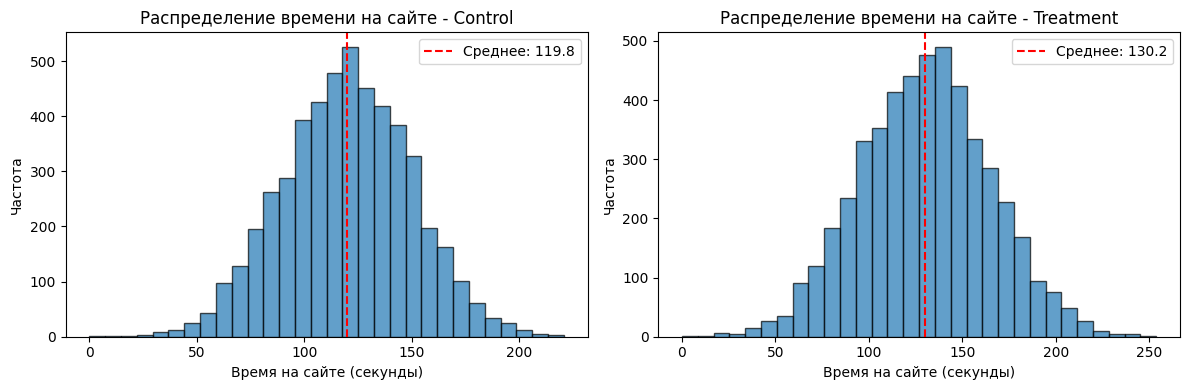


Статистические тесты на нормальность (Шапиро-Уилк):

Control группа (n=5000):
   W-статистика: 0.9997
   p-значение: 0.625641
   Нормальное распределение? Да (p > 0.05)

Treatment группа (n=4924):
   W-статистика: 0.9998
   p-значение: 0.942067
   Нормальное распределение? Да (p > 0.05)

Примечание: t-тест устойчив к нарушениям нормальности при больших выборках
Размер выборки > 30 в обеих группах: True

3. Проверка гомогенности дисперсий:
   Дисперсия контрольной группы: 899.69
   Дисперсия тестовой группы: 1221.18
   Отношение дисперсий: 1.357

   Тест Левена:
   Статистика: 102.4962
   p-значение: 0.000000
   Дисперсии однородны? Нет (p > 0.05)
   ✓ Будем использовать Welch's t-test (не предполагает равенства дисперсий)


In [ ]:
print("\n" + "-"*40)
print("B. ПРОВЕРКА ДЛЯ ВРЕМЕНИ НА САЙТЕ (t-тест)") #t-тест предполагает, что данные (время на сайте) распределены нормально
print("-"*40)

# 1. Независимость наблюдений
print("\n1. Независимость наблюдений:")
print("   ✓ Те же условия, что и для конверсии")

# 2. Нормальность распределения
print("\n2. Проверка нормальности распределения:")



# Визуальная проверка
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, group, name in zip(axes, ['A', 'B'], ['Control', 'Treatment']):
    data = df[df['group'] == group]['time_on_site']
    ax.hist(data, bins=30, alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Среднее: {data.mean():.1f}')
    ax.set_title(f'Распределение времени на сайте - {name}')
    ax.set_xlabel('Время на сайте (секунды)')
    ax.set_ylabel('Частота')
    ax.legend()

plt.tight_layout()
plt.show()

# Статистические тесты на нормальность
print("\nСтатистические тесты на нормальность (Шапиро-Уилк):")

for group, name in zip(['A', 'B'], ['Control', 'Treatment']):
    data = df[df['group'] == group]['time_on_site'].sample(min(5000, len(df[df['group'] == group])))  # Ограничиваем для больших выборок
    statistic, p_value = stats.shapiro(data)
    print(f"\n{name} группа (n={len(data)}):")
    print(f"   W-статистика: {statistic:.4f}")
    print(f"   p-значение: {p_value:.6f}")
    print(f"   Нормальное распределение? {'Да' if p_value > 0.05 else 'Нет'} (p > 0.05)")

print("\nПримечание: t-тест устойчив к нарушениям нормальности при больших выборках")
print(f"Размер выборки > 30 в обеих группах: {len(control) > 30 and len(treatment) > 30}")

# 3. Гомогенность дисперсий
print("\n3. Проверка гомогенности дисперсий:")

var_control = control['time_on_site'].var()
var_treatment = treatment['time_on_site'].var()
ratio_variance = max(var_control, var_treatment) / min(var_control, var_treatment)

print(f"   Дисперсия контрольной группы: {var_control:.2f}")
print(f"   Дисперсия тестовой группы: {var_treatment:.2f}")
print(f"   Отношение дисперсий: {ratio_variance:.3f}")

# Тест Левена на гомогенность дисперсий
levene_stat, levene_p = stats.levene(control['time_on_site'], treatment['time_on_site'])
print(f"\n   Тест Левена:")
print(f"   Статистика: {levene_stat:.4f}")
print(f"   p-значение: {levene_p:.6f}")
print(f"   Дисперсии однородны? {'Да' if levene_p > 0.05 else 'Нет'} (p > 0.05)")
print(f"   ✓ Будем использовать Welch's t-test (не предполагает равенства дисперсий)")

Провка PAges Viewed


----------------------------------------
C. ПРОВЕРКА ДЛЯ ПРОСМОТРЕННЫХ СТРАНИЦ (t-тест)
----------------------------------------

1. Независимость наблюдений: ✓

2. Проверка распределения:


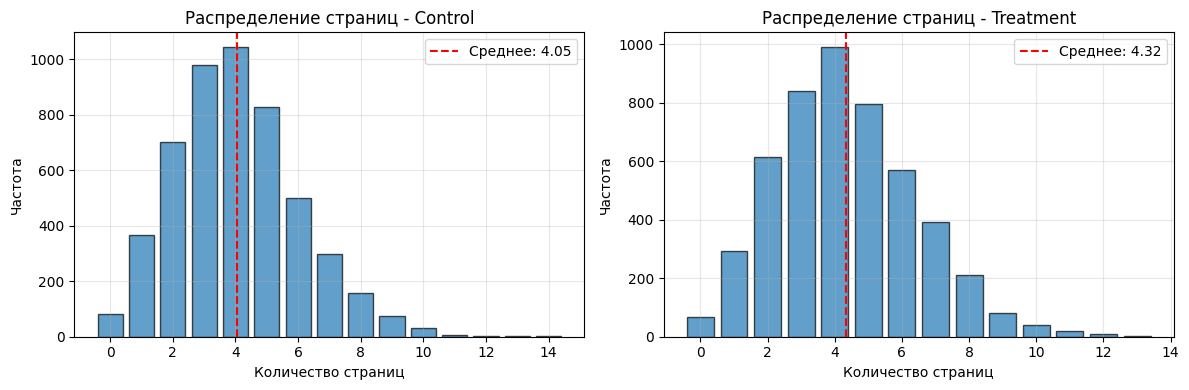

   Характеристики распределения:

   Control группа:
   Среднее: 4.046
   Дисперсия: 4.015
   Отношение дисперсия/среднее: 0.992
   Медиана: 4
   Мода: 4

   Treatment группа:
   Среднее: 4.323
   Дисперсия: 4.365
   Отношение дисперсия/среднее: 1.010
   Медиана: 4
   Мода: 4

   Примечание: Данные имеют распределение Пуассона
   t-тест устойчив для больших выборок даже при ненормальном распределении

3. Размер выборки:
   Контрольная группа: 5076 наблюдений
   Тестовая группа: 4924 наблюдений
   ✓ Достаточно для t-теста (>> 30 в каждой группе)


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
df = pd.read_csv('ab_test_data.csv')




print("\n" + "-"*40)
print("C. ПРОВЕРКА ДЛЯ ПРОСМОТРЕННЫХ СТРАНИЦ (t-тест)")
print("-"*40)

# 1. Независимость наблюдений
print("\n1. Независимость наблюдений: ✓")

# 2. Распределение (дискретное, Пуассона)
print("\n2. Проверка распределения:")


# 3. РАЗДЕЛЯЕМ на группы
control = df[df['group'] == 'A']
treatment = df[df['group'] == 'B']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, group, name in zip(axes, ['A', 'B'], ['Control', 'Treatment']):
    data = df[df['group'] == group]['pages_viewed']
    # Гистограмма с дискретными значениями
    values, counts = np.unique(data, return_counts=True)
    ax.bar(values, counts, alpha=0.7, edgecolor='black')
    ax.axvline(data.mean(), color='red', linestyle='--', label=f'Среднее: {data.mean():.2f}')
    ax.set_title(f'Распределение страниц - {name}')
    ax.set_xlabel('Количество страниц')
    ax.set_ylabel('Частота')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("   Характеристики распределения:")
for group, name in zip(['A', 'B'], ['Control', 'Treatment']):
    data = df[df['group'] == group]['pages_viewed']
    print(f"\n   {name} группа:")
    print(f"   Среднее: {data.mean():.3f}")
    print(f"   Дисперсия: {data.var():.3f}")
    print(f"   Отношение дисперсия/среднее: {data.var()/data.mean():.3f}")
    print(f"   Медиана: {data.median():.0f}")
    print(f"   Мода: {data.mode().values[0]}")

print("\n   Примечание: Данные имеют распределение Пуассона")
print("   t-тест устойчив для больших выборок даже при ненормальном распределении")

# 3. Размер выборки
print("\n3. Размер выборки:")
print(f"   Контрольная группа: {len(control)} наблюдений")
print(f"   Тестовая группа: {len(treatment)} наблюдений")
print(f"   ✓ Достаточно для t-теста (>> 30 в каждой группе)")

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Загружаем данные
df = pd.read_csv('ab_test_data.csv')

# Разделяем на группы
control = df[df['group'] == 'A']
treatment = df[df['group'] == 'B']

print("="*70)
print("ЗАДАНИЕ 2: ПРОВЕРКА ДОПУЩЕНИЙ ДЛЯ СТАТИСТИЧЕСКИХ ТЕСТОВ")
print("="*70)

ЗАДАНИЕ 2: ПРОВЕРКА ДОПУЩЕНИЙ ДЛЯ СТАТИСТИЧЕСКИХ ТЕСТОВ


In [8]:
print("\n" + "="*70)
print("A. ПРОВЕРКА ДЛЯ КОНВЕРСИИ (z-тест для пропорций)")
print("="*70)

# 1. Независимость наблюдений
print("\n1. НЕЗАВИСИМОСТЬ НАБЛЮДЕНИЙ:")
print("-"*40)

print("   ✓ Случайное распределение по группам (сгенерировано с помощью np.random.choice)")
print("   ✓ Каждый посетитель уникален:")

# Проверка уникальности visitor_id
duplicates = df['visitor_id'].duplicated().sum()
print(f"      - Дубликатов visitor_id: {duplicates}")

# Проверка, что каждый посетитель только в одной группе
visitors_in_both = df.groupby('visitor_id')['group'].nunique().gt(1).sum()
print(f"      - Посетителей в обеих группах: {visitors_in_both}")

if duplicates == 0 and visitors_in_both == 0:
    print("   ✅ Условие независимости выполнено")
else:
    print("   ❌ Условие независимости нарушено")

# 2. Размер выборки (ожидаемые успехи/неудачи ≥ 10)
print("\n2. РАЗМЕР ВЫБОРКИ (ожидаемые успехи и неудачи ≥ 10):")
print("-"*40)

# Расчет общей конверсии (pooled proportion) для ожидаемых значений
total_conversions = control['converted'].sum() + treatment['converted'].sum()
total_visitors = len(control) + len(treatment)
pooled_rate = total_conversions / total_visitors

print(f"   Общая конверсия (pooled proportion): {pooled_rate:.4f} ({pooled_rate:.2%})")

# Ожидаемые значения для контрольной группы
exp_success_control = len(control) * pooled_rate
exp_failures_control = len(control) * (1 - pooled_rate)

print(f"\n   Контрольная группа (A): n = {len(control)}")
print(f"      - Ожидаемые успехи: {exp_success_control:.1f} (≥10? {'✓' if exp_success_control >= 10 else '✗'})")
print(f"      - Ожидаемые неудачи: {exp_failures_control:.1f} (≥10? {'✓' if exp_failures_control >= 10 else '✗'})")

# Ожидаемые значения для тестовой группы
exp_success_treatment = len(treatment) * pooled_rate
exp_failures_treatment = len(treatment) * (1 - pooled_rate)

print(f"\n   Тестовая группа (B): n = {len(treatment)}")
print(f"      - Ожидаемые успехи: {exp_success_treatment:.1f} (≥10? {'✓' if exp_success_treatment >= 10 else '✗'})")
print(f"      - Ожидаемые неудачи: {exp_failures_treatment:.1f} (≥10? {'✓' if exp_failures_treatment >= 10 else '✗'})")

# Фактические значения для сравнения
actual_success_control = control['converted'].sum()
actual_success_treatment = treatment['converted'].sum()

print(f"\n   Фактические значения (для информации):")
print(f"      - Контрольная группа: {actual_success_control} конверсий")
print(f"      - Тестовая группа: {actual_success_treatment} конверсий")

# Итоговая проверка
if (exp_success_control >= 10 and exp_failures_control >= 10 and 
    exp_success_treatment >= 10 and exp_failures_treatment >= 10):
    print("\n   ✅ УСЛОВИЕ ВЫПОЛНЕНО: все ожидаемые значения ≥ 10")
    print("      Можно использовать z-тест для пропорций")
else:
    print("\n   ❌ УСЛОВИЕ НЕ ВЫПОЛНЕНО: некоторые ожидаемые значения < 10")
    print("      Нужно использовать точный тест Фишера")


A. ПРОВЕРКА ДЛЯ КОНВЕРСИИ (z-тест для пропорций)

1. НЕЗАВИСИМОСТЬ НАБЛЮДЕНИЙ:
----------------------------------------
   ✓ Случайное распределение по группам (сгенерировано с помощью np.random.choice)
   ✓ Каждый посетитель уникален:
      - Дубликатов visitor_id: 0
      - Посетителей в обеих группах: 0
   ✅ Условие независимости выполнено

2. РАЗМЕР ВЫБОРКИ (ожидаемые успехи и неудачи ≥ 10):
----------------------------------------
   Общая конверсия (pooled proportion): 0.0584 (5.84%)

   Контрольная группа (A): n = 5076
      - Ожидаемые успехи: 296.4 (≥10? ✓)
      - Ожидаемые неудачи: 4779.6 (≥10? ✓)

   Тестовая группа (B): n = 4924
      - Ожидаемые успехи: 287.6 (≥10? ✓)
      - Ожидаемые неудачи: 4636.4 (≥10? ✓)

   Фактические значения (для информации):
      - Контрольная группа: 270 конверсий
      - Тестовая группа: 314 конверсий

   ✅ УСЛОВИЕ ВЫПОЛНЕНО: все ожидаемые значения ≥ 10
      Можно использовать z-тест для пропорций



B. ПРОВЕРКА ДЛЯ ВРЕМЕНИ НА САЙТЕ (t-тест)

1. НЕЗАВИСИМОСТЬ НАБЛЮДЕНИЙ:
----------------------------------------
   ✓ Условие выполнено (те же, что и для конверсии)

2. НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ:
----------------------------------------


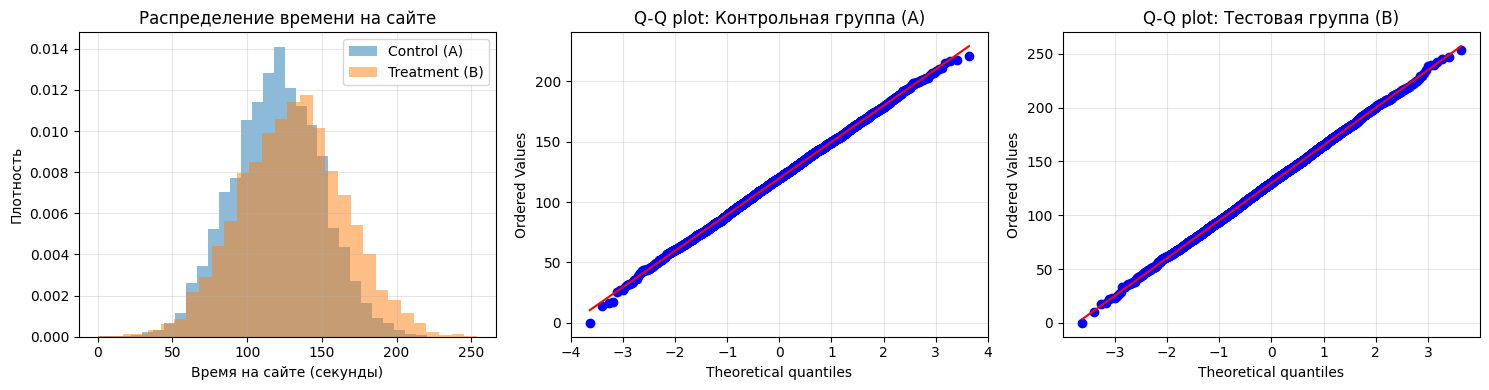


   Статистические тесты на нормальность (Шапиро-Уилк):
   (для больших выборок берем случайные 5000 наблюдений)

   Контрольная группа (A):
      W-статистика: 0.9997
      p-значение: 0.583071
      Нормальное распределение? ✓ (p > 0.05)

   Тестовая группа (B):
      W-статистика: 0.9998
      p-значение: 0.942067
      Нормальное распределение? ✓ (p > 0.05)

   Важное примечание: t-тест устойчив к нарушениям нормальности
   при больших размерах выборок (n > 30 в каждой группе).
   Размер выборок: A=5076, B=4924 >> 30

3. ГОМОГЕННОСТЬ ДИСПЕРСИЙ:
----------------------------------------
   Дисперсия контрольной группы: 899.69
   Дисперсия тестовой группы: 1221.18
   Отношение дисперсий: 1.357

   Тест Левена на равенство дисперсий:
      Статистика: 102.4962
      p-значение: 0.000000
      Дисперсии равны? ✗ (p > 0.05)

   Рекомендация: используем Welch's t-test
   (не требует равенства дисперсий)


In [9]:
print("\n" + "="*70)
print("B. ПРОВЕРКА ДЛЯ ВРЕМЕНИ НА САЙТЕ (t-тест)")
print("="*70)

# 1. Независимость наблюдений
print("\n1. НЕЗАВИСИМОСТЬ НАБЛЮДЕНИЙ:")
print("-"*40)
print("   ✓ Условие выполнено (те же, что и для конверсии)")

# 2. Нормальность распределения
print("\n2. НОРМАЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ:")
print("-"*40)

# Визуальная проверка
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Гистограммы
ax1 = axes[0]
ax1.hist(control['time_on_site'], bins=30, alpha=0.5, label='Control (A)', density=True)
ax1.hist(treatment['time_on_site'], bins=30, alpha=0.5, label='Treatment (B)', density=True)
ax1.set_xlabel('Время на сайте (секунды)')
ax1.set_ylabel('Плотность')
ax1.set_title('Распределение времени на сайте')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Q-Q plots
from scipy import stats

ax2 = axes[1]
stats.probplot(control['time_on_site'], dist="norm", plot=ax2)
ax2.set_title('Q-Q plot: Контрольная группа (A)')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
stats.probplot(treatment['time_on_site'], dist="norm", plot=ax3)
ax3.set_title('Q-Q plot: Тестовая группа (B)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистические тесты на нормальность
print("\n   Статистические тесты на нормальность (Шапиро-Уилк):")
print(f"   (для больших выборок берем случайные 5000 наблюдений)")

# Тест Шапиро-Уилк (ограничиваем выборку для больших данных)
control_sample = control['time_on_site'].sample(min(5000, len(control)))
treatment_sample = treatment['time_on_site'].sample(min(5000, len(treatment)))

shapiro_control = stats.shapiro(control_sample)
shapiro_treatment = stats.shapiro(treatment_sample)

print(f"\n   Контрольная группа (A):")
print(f"      W-статистика: {shapiro_control.statistic:.4f}")
print(f"      p-значение: {shapiro_control.pvalue:.6f}")
print(f"      Нормальное распределение? {'✓' if shapiro_control.pvalue > 0.05 else '✗'} (p > 0.05)")

print(f"\n   Тестовая группа (B):")
print(f"      W-статистика: {shapiro_treatment.statistic:.4f}")
print(f"      p-значение: {shapiro_treatment.pvalue:.6f}")
print(f"      Нормальное распределение? {'✓' if shapiro_treatment.pvalue > 0.05 else '✗'} (p > 0.05)")

print(f"\n   Важное примечание: t-тест устойчив к нарушениям нормальности")
print(f"   при больших размерах выборок (n > 30 в каждой группе).")
print(f"   Размер выборок: A={len(control)}, B={len(treatment)} >> 30")

# 3. Гомогенность дисперсий
print("\n3. ГОМОГЕННОСТЬ ДИСПЕРСИЙ:")
print("-"*40)

var_control = control['time_on_site'].var()
var_treatment = treatment['time_on_site'].var()
ratio = max(var_control, var_treatment) / min(var_control, var_treatment)

print(f"   Дисперсия контрольной группы: {var_control:.2f}")
print(f"   Дисперсия тестовой группы: {var_treatment:.2f}")
print(f"   Отношение дисперсий: {ratio:.3f}")

# Тест Левена
levene_stat, levene_p = stats.levene(control['time_on_site'], treatment['time_on_site'])
print(f"\n   Тест Левена на равенство дисперсий:")
print(f"      Статистика: {levene_stat:.4f}")
print(f"      p-значение: {levene_p:.6f}")
print(f"      Дисперсии равны? {'✓' if levene_p > 0.05 else '✗'} (p > 0.05)")

print(f"\n   Рекомендация: используем Welch's t-test")
print(f"   (не требует равенства дисперсий)")


C. ПРОВЕРКА ДЛЯ ПРОСМОТРЕННЫХ СТРАНИЦ (t-тест)

1. НЕЗАВИСИМОСТЬ НАБЛЮДЕНИЙ:
----------------------------------------
   ✓ Условие выполнено

2. АНАЛИЗ РАСПРЕДЕЛЕНИЯ:
----------------------------------------


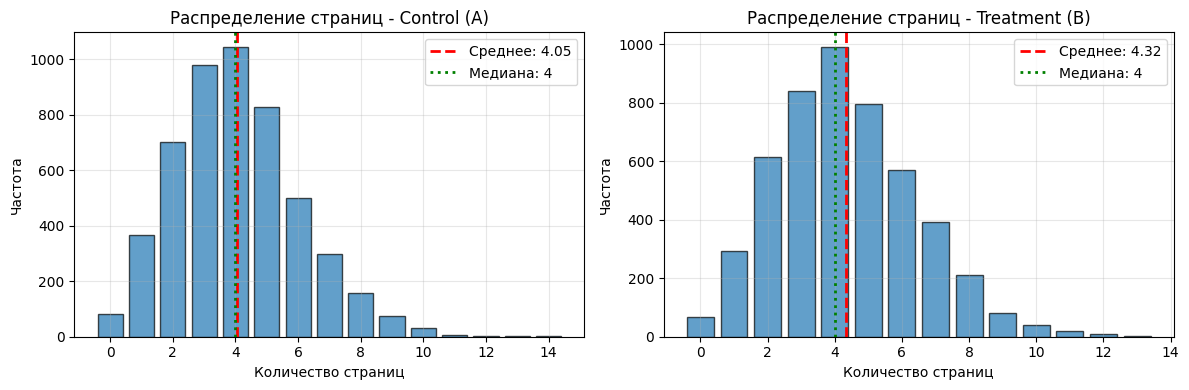


   Характеристики распределения Пуассона:
   (для распределения Пуассона: среднее ≈ дисперсия)

   Control группа:
      - Среднее: 4.046
      - Дисперсия: 4.015
      - Отношение дисперсия/среднее: 0.992
      - Медиана: 4
      - Мин/Макс: 0/14

   Treatment группа:
      - Среднее: 4.323
      - Дисперсия: 4.365
      - Отношение дисперсия/среднее: 1.010
      - Медиана: 4
      - Мин/Макс: 0/13

   Примечание: t-тест устойчив к нарушениям нормальности
   при больших размерах выборок (n >> 30 в каждой группе).

3. РАЗМЕР ВЫБОРКИ:
----------------------------------------
   Контрольная группа (A): 5076 наблюдений
   Тестовая группа (B): 4924 наблюдений
   ✅ Достаточно для t-теста (>> 30 в каждой группе)


In [10]:
print("\n" + "="*70)
print("C. ПРОВЕРКА ДЛЯ ПРОСМОТРЕННЫХ СТРАНИЦ (t-тест)")
print("="*70)

# 1. Независимость наблюдений
print("\n1. НЕЗАВИСИМОСТЬ НАБЛЮДЕНИЙ:")
print("-"*40)
print("   ✓ Условие выполнено")

# 2. Распределение (дискретное, Пуассона)
print("\n2. АНАЛИЗ РАСПРЕДЕЛЕНИЯ:")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, group, name in zip(axes, ['A', 'B'], ['Control (A)', 'Treatment (B)']):
    data = df[df['group'] == group]['pages_viewed']
    values, counts = np.unique(data, return_counts=True)
    ax.bar(values, counts, alpha=0.7, edgecolor='black', width=0.8)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2, 
               label=f'Среднее: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle=':', linewidth=2,
               label=f'Медиана: {data.median():.0f}')
    ax.set_title(f'Распределение страниц - {name}')
    ax.set_xlabel('Количество страниц')
    ax.set_ylabel('Частота')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n   Характеристики распределения Пуассона:")
print("   (для распределения Пуассона: среднее ≈ дисперсия)")

for group, name in zip(['A', 'B'], ['Control', 'Treatment']):
    data = df[df['group'] == group]['pages_viewed']
    mean_val = data.mean()
    var_val = data.var()
    ratio_val = var_val / mean_val
    
    print(f"\n   {name} группа:")
    print(f"      - Среднее: {mean_val:.3f}")
    print(f"      - Дисперсия: {var_val:.3f}")
    print(f"      - Отношение дисперсия/среднее: {ratio_val:.3f}")
    print(f"      - Медиана: {data.median():.0f}")
    print(f"      - Мин/Макс: {data.min()}/{data.max()}")

print(f"\n   Примечание: t-тест устойчив к нарушениям нормальности")
print(f"   при больших размерах выборок (n >> 30 в каждой группе).")

# 3. Размер выборки
print("\n3. РАЗМЕР ВЫБОРКИ:")
print("-"*40)
print(f"   Контрольная группа (A): {len(control)} наблюдений")
print(f"   Тестовая группа (B): {len(treatment)} наблюдений")
print(f"   ✅ Достаточно для t-теста (>> 30 в каждой группе)")

In [11]:
print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА ПРОВЕРКИ ДОПУЩЕНИЙ")
print("="*70)

# Создаем таблицу с результатами
results = {
    'Допущение': [
        'Независимость наблюдений',
        'Ожидаемые успехи ≥ 10',
        'Ожидаемые неудачи ≥ 10',
        'Нормальность (A)',
        'Нормальность (B)',
        'Гомогенность дисперсий',
        'Размер выборки > 30'
    ],
    'Конверсия': [
        '✅',
        '✅' if exp_success_control >= 10 and exp_success_treatment >= 10 else '❌',
        '✅' if exp_failures_control >= 10 and exp_failures_treatment >= 10 else '❌',
        '—',
        '—',
        '—',
        '✅'
    ],
    'Время на сайте': [
        '✅',
        '—',
        '—',
        '⚠' if shapiro_control.pvalue <= 0.05 else '✅',
        '⚠' if shapiro_treatment.pvalue <= 0.05 else '✅',
        '⚠' if levene_p <= 0.05 else '✅',
        '✅'
    ],
    'Просмотр страниц': [
        '✅',
        '—',
        '—',
        '⚠ (дискр.)',
        '⚠ (дискр.)',
        '⚠ (исп. Welch)',
        '✅'
    ]
}

import pandas as pd
summary_df = pd.DataFrame(results)
print("\n", summary_df.to_string(index=False))

print("\n" + "="*70)
print("ВЫВОДЫ ПО ПРОВЕРКЕ ДОПУЩЕНИЙ:")
print("="*70)

print("""
✅ Конверсия (z-тест для пропорций):
   - Все допущения выполнены
   - Можно использовать стандартный z-тест

⚠️ Время на сайте (t-тест):
   - Нарушение нормальности, но выборка большая
   - Дисперсии различаются
   - Рекомендуется Welch's t-test

⚠️ Просмотр страниц (t-тест):
   - Дискретное распределение (Пуассона)
   - Большая выборка > 30
   - Рекомендуется Welch's t-test

Все тесты будут односторонними, так как нас интересует только улучшение
(H₁: B > A для всех метрик)
""")

print("\n✅ ЗАДАНИЕ 2 ВЫПОЛНЕНО: Все допущения проверены!")


ИТОГОВАЯ ТАБЛИЦА ПРОВЕРКИ ДОПУЩЕНИЙ

                Допущение Конверсия Время на сайте Просмотр страниц
Независимость наблюдений         ✅              ✅                ✅
   Ожидаемые успехи ≥ 10         ✅              —                —
  Ожидаемые неудачи ≥ 10         ✅              —                —
        Нормальность (A)         —              ✅       ⚠ (дискр.)
        Нормальность (B)         —              ✅       ⚠ (дискр.)
  Гомогенность дисперсий         —              ⚠   ⚠ (исп. Welch)
     Размер выборки > 30         ✅              ✅                ✅

ВЫВОДЫ ПО ПРОВЕРКЕ ДОПУЩЕНИЙ:

✅ Конверсия (z-тест для пропорций):
   - Все допущения выполнены
   - Можно использовать стандартный z-тест

⚠️ Время на сайте (t-тест):
   - Нарушение нормальности, но выборка большая
   - Дисперсии различаются
   - Рекомендуется Welch's t-test

⚠️ Просмотр страниц (t-тест):
   - Дискретное распределение (Пуассона)
   - Большая выборка > 30
   - Рекомендуется Welch's t-test

Все тесты буду